# Rz(pi/2) shorter-gate optimization

Optimize the Fourier coefficients already given in `pulses/Rz_pi_2.csv`, trying to make the gate run faster (shorter total duration) while minimizing infidelity of the **full joint-parity sandwich** `U_sim_1 = U_step_1_3 . (Sz*X_cav) . U_step_1_3` against its target -- checked **per block** (`[0:2,0:2]` vs I, `[2:6,2:6]` vs `(X_cav*Sz)[2:6,2:6]`, `[6:8,6:8]` vs I), exactly matching cells 20/24/26 of *Paper_results_and_figures.ipynb*. Each block only needs to match its own target independently -- no shared/mutual phase is required across blocks, which matters (see below).

**History of getting here** (kept for context): an earlier version of this notebook optimized a *reduced single-qubit* model against `tools.expm([0,0,1], pi/4)` for a single fixed photon number. That missed two things, found the hard way: (1) the real gate must work for **both** `n_a=0` and `n_a=1` simultaneously with the *same* fields (the whole point of `Rz_pi_2` being "dephasing-robust"), and (2) even matching both sectors independently isn't enough -- the full sandwich has *relative-phase* structure between sectors that per-sector matching against an arbitrary-phase target cannot see. The fix: optimize the full 8x8 embedding directly against the real per-block target used elsewhere in this repo.

Operators, same convention as the other notebooks in this repo.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt

import tools
import os
os.chdir("/home/filippos-dakis/Documents/Github_Repos/Dual-rail-Erasure-Qubits")


In [2]:
# Operators, same convention as Paper_results_and_figures.ipynb / Pulse_optimization.ipynb
I = qt.qeye(2)
X = qt.sigmax()
Y = qt.sigmay()
Z = qt.sigmaz()

N_fock = 2

a  = qt.tensor(qt.destroy(N_fock), qt.qeye(N_fock), qt.qeye(2))
b  = qt.tensor(qt.qeye(N_fock), qt.destroy(N_fock), qt.qeye(2))
Sz = qt.tensor(qt.qeye(N_fock), qt.qeye(N_fock), qt.sigmaz())
Sx = qt.tensor(qt.qeye(N_fock), qt.qeye(N_fock), qt.sigmax())
Sy = qt.tensor(qt.qeye(N_fock), qt.qeye(N_fock), qt.sigmay())

n_a = a.dag() * a
n_b = b.dag() * b

chi = -1   # MHz


Load `Rz_pi_2.csv` and build the joint-parity target pieces (`X_cav`, `u_jp_target_b`). Free parameters: the 11 `cn`-derived reals for `x_control`, plus a **low-order (2-harmonic), slowly-varying** `z_tr(t)` Fourier series (5 reals) added on top of the original fixed `z_control=chi/2` design. `x_control`'s warm-start amplitude is scaled by `n_factor` (`H'(t')=H(t)*n_factor` under `t'=t/n_factor`); `z_tr` starts at 0, exactly reproducing the original pulse at `n_factor=1`.

**`N_t=1000`** for the optimization grid, not fewer: a coarser grid (400 was tried first) lets the optimizer find a solution that's exact for its own coarse piecewise-constant approximation but doesn't generalize to the true continuous dynamics -- confirmed by an independent QuTiP cross-check dropping from 5e-3 to 4e-7 infidelity when the training grid was refined from 400 to 1000 points.

In [3]:
import numpy as np
import jax
import jax.numpy as jnp
jax.config.update("jax_enable_x64", True)
import dynamiqs as dq

# Full 8x8 embedding this time (cavity_a x cavity_b x transmon), matching
# Paper_results_and_figures.ipynb exactly -- optimizing directly against the real
# joint-parity target u_jp_target_b (the Rz . (Sz*X_cav) . Rz sandwich), not a
# per-photon-number surrogate (which is phase-blind and misses relative phase
# mismatches between n_a sectors -- see the earlier investigation).
from scipy.linalg import block_diag

P_00 = qt.tensor(qt.basis(N_fock,0)*qt.basis(N_fock,0).dag(), qt.basis(N_fock,0)*qt.basis(N_fock,0).dag(), qt.qeye(2))
P_11 = qt.tensor(qt.basis(N_fock,1)*qt.basis(N_fock,1).dag(), qt.basis(N_fock,1)*qt.basis(N_fock,1).dag(), qt.qeye(2))
X_cav = (a.dag()*b + a*b.dag()) + P_00 + P_11
u_jp_target_b = block_diag(-I.full(), (X_cav*Sz)[2:6, 2:6], I.full())

sandwich_op_np = (Sz * X_cav).full()   # fixed, applied between the two Rz_pi_2 steps

cn0, ampl0, ct0, T_g0, speed0 = tools.read_dict('Rz_pi_2')
T_g_times_chi0 = 2 * ct0 * T_g0 / np.abs(chi)

n_factor = 2.0
T_new = T_g_times_chi0 / n_factor

N_t = 1000
t_grid = np.linspace(0.0, T_new, N_t)
s_grid = t_grid / T_new * T_g0

L = len(cn0)
period = T_g0
w = 2*np.pi/period
harmonics = np.arange(1, L)
cos_mat = np.cos(np.outer(s_grid, harmonics)*w)
sin_mat = np.sin(np.outer(s_grid, harmonics)*w)
Phi = jnp.asarray(np.concatenate([np.ones((N_t,1)), cos_mat, sin_mat], axis=1))
x_scale = chi / (2*ct0)
n_cn_params = 2*L - 1

# z_tr(t): low-order (z_order harmonics), slowly-varying, per your suggestion.
z_order = 2
z_harmonics = np.arange(1, z_order+1)
z_cos = np.cos(np.outer(t_grid, z_harmonics)*(2*np.pi/T_new))
z_sin = np.sin(np.outer(t_grid, z_harmonics)*(2*np.pi/T_new))
Phi_z = jnp.asarray(np.concatenate([np.ones((N_t,1)), z_cos, z_sin], axis=1))
n_z_params = 2*z_order + 1

n_params_total = n_cn_params + n_z_params

def unpack(p):
    return p[:n_cn_params], p[n_cn_params:]   # (cn_realparams, z_realparams)

def cn_to_realparams(cn, scale=1.0):
    c = np.zeros(2*len(cn)-1)
    c[0] = np.real(cn[0]) * scale
    for n in range(1, len(cn)):
        c[n]            = np.real(cn[n]) * scale
        c[len(cn)-1+n]  = np.imag(cn[n]) * scale
    return c

# warm start: original cn (ampl folded in) scaled by n_factor. z_tr(t) is an
# ADDITIVE correction on top of the original design's fixed z_control=chi/2 (added
# in build_H below), so z_tr=0 exactly reproduces the original pulse at n_factor=1.
x0 = np.concatenate([cn_to_realparams(cn0, scale=ampl0 * n_factor), np.zeros(n_z_params)])
print("total params:", x0.size, " (", n_cn_params, "for x_control +", n_z_params, "for z_tr )")
print("T_g_times_chi0=", T_g_times_chi0, " T_new=", T_new)


An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


total params: 16  ( 11 for x_control + 5 for z_tr )
T_g_times_chi0= 15.715705958740985  T_new= 7.8578529793704925


Build `H(t) = -(chi/2)*n_a*Sz` (fixed) `+ x_control(t)*(Sx/2)` (free) `+ (chi/2 + z_tr(t))*(Sz/2)` (free), propagate the full 8x8 system once, form the sandwich `U_sim_1`, and sum the three per-block infidelities (`gate_fidelity_jax` is an exact JAX translation of `tools.calculate_gate_fidelity`).

In [4]:
op_detun_np = (n_a * Sz).full()   # FIXED: -(chi/2) coefficient, intrinsic dispersive coupling
op_x_np     = (Sx/2).full()
op_z_np     = (Sz/2).full()
sandwich_jax = jnp.asarray(sandwich_op_np)

target_00_jax   = jnp.asarray(I.full())
target_code_jax = jnp.asarray((X_cav*Sz)[2:6, 2:6])
target_11_jax   = jnp.asarray(I.full())

def gate_fidelity_jax(U, target):
    """Exact JAX translation of tools.calculate_gate_fidelity."""
    d = target.shape[0]
    M = jnp.conj(target).T @ U
    tr_MMdag = jnp.trace(M @ jnp.conj(M).T).real
    tr_M = jnp.trace(M)
    tr_sq = (tr_M * jnp.conj(tr_M)).real
    return (tr_MMdag + tr_sq) / (d*(d+1))

def build_H(params_flat):
    cn_p, z_p = unpack(params_flat)
    x_control = x_scale * (Phi @ cn_p)
    z_tr = Phi_z @ z_p
    H = (dq.pwc(t_grid, jnp.full(t_grid.shape, -chi/2)[:-1], dq.asqarray(op_detun_np))
       + dq.pwc(t_grid, x_control[:-1],                      dq.asqarray(op_x_np))
       + dq.pwc(t_grid, (chi/2 + z_tr)[:-1],                 dq.asqarray(op_z_np)))
    return H

def raw_infid(params_flat):
    """Per-block check, exactly matching cells 20/24/26 of
    Paper_results_and_figures.ipynb: each block of U_sim_1 against its OWN target,
    independently -- no shared/mutual phase required across blocks."""
    H = build_H(params_flat)
    result = dq.sepropagator(H, tsave=[0.0, t_grid[-1]], method=dq.method.Expm())
    U_step = result.propagators.to_jax()[-1]
    U_sim_1 = U_step @ sandwich_jax @ U_step

    infid_00   = 1.0 - gate_fidelity_jax(U_sim_1[0:2, 0:2],   target_00_jax)
    infid_code = 1.0 - gate_fidelity_jax(U_sim_1[2:6, 2:6],   target_code_jax)
    infid_11   = 1.0 - gate_fidelity_jax(U_sim_1[6:8, 6:8],   target_11_jax)
    return infid_00 + infid_code + infid_11

infid0 = float(raw_infid(jnp.asarray(x0)))
print(f"baseline (warm start, n_factor={n_factor}): sum infid = {infid0:.6e}")


baseline (warm start, n_factor=2.0): sum infid = 3.391237e-01


Screen the warm start plus 8 random starting shapes, keep the best, done -- L-BFGS-B with tight tolerances converges to machine precision directly from several of the starts at `n_factor=2`.

In [5]:
import time
from scipy.optimize import minimize

rng = np.random.default_rng(0)

def objective(p_np):
    p = jnp.asarray(p_np)
    val, grad = jax.value_and_grad(raw_infid)(p)
    return float(val), np.asarray(grad, dtype=np.float64)

decay_cn = 1.0 / (1.0 + np.concatenate([[0], harmonics, harmonics]))
decay_z  = 1.0 / (1.0 + np.concatenate([[0], z_harmonics, z_harmonics]))
decay = np.concatenate([decay_cn, decay_z])
scale = np.abs(x0).max() if np.abs(x0).max() > 0 else 1.0
starts = [x0] + [rng.normal(0.0, scale, size=n_params_total) * decay for _ in range(5)]

t0 = time.time()
best = None
for i, x_start in enumerate(starts):
    r = minimize(objective, x_start, jac=True, method="L-BFGS-B",
                 options={"maxiter": 400, "ftol": 1e-14, "gtol": 1e-12})
    infid = float(raw_infid(jnp.asarray(r.x)))
    label = "x0 (warm start)" if i == 0 else f"random #{i}"
    print(f"  {label:18s}: sum infid = {infid:.6e}")
    if best is None or infid < best[0]:
        best = (infid, r.x)
t1 = time.time()
print(f"n_factor={n_factor}: best sum infid = {best[0]:.6e}   ({t1-t0:.1f}s)")


  x0 (warm start)   : sum infid = -4.529710e-14
  random #1         : sum infid = -4.263256e-14
  random #2         : sum infid = -6.350476e-14
  random #3         : sum infid = 8.000000e-01
  random #4         : sum infid = -9.436896e-15
  random #5         : sum infid = -8.881784e-15
  random #6         : sum infid = 8.000000e-01
  random #7         : sum infid = 6.640858e-01
  random #8         : sum infid = 6.640858e-01
n_factor=2.0: best sum infid = -6.350476e-14   (152.5s)


Independent cross-check: re-evaluate the optimized fields with plain QuTiP on the original fine grid (N_points=4096), calling `tools.calculate_gate_fidelity` directly per block -- exactly matching cells 20/24/26 of *Paper_results_and_figures.ipynb*.

In [6]:
# Independent cross-check: re-evaluate the optimized fields with plain QuTiP on the
# original fine grid (N_points=4096), calling tools.calculate_gate_fidelity
# directly, per block -- exactly matching cells 20/24/26 of
# Paper_results_and_figures.ipynb.
cn_params_opt, z_params_opt = unpack(jnp.asarray(best[1]))
cn_params_opt = np.asarray(cn_params_opt)
z_params_opt = np.asarray(z_params_opt)

N_points = 2**12
time_gate_1_3 = np.linspace(0, T_new, N_points)
s_full = time_gate_1_3 / T_new * T_g0
cos_full = np.cos(np.outer(s_full, harmonics)*w)
sin_full = np.sin(np.outer(s_full, harmonics)*w)
Phi_full = np.concatenate([np.ones((N_points,1)), cos_full, sin_full], axis=1)
x_control = x_scale * (Phi_full @ cn_params_opt)
y_control = np.zeros_like(x_control)
g_control = np.zeros_like(x_control)

z_cos_full = np.cos(np.outer(time_gate_1_3, z_harmonics)*(2*np.pi/T_new))
z_sin_full = np.sin(np.outer(time_gate_1_3, z_harmonics)*(2*np.pi/T_new))
Phi_z_full = np.concatenate([np.ones((N_points,1)), z_cos_full, z_sin_full], axis=1)
z_control = chi/2 + Phi_z_full @ z_params_opt

H = [[n_a * Sz,                   -(chi/2)],
     [(a.dag()*b + a*b.dag())/2, g_control],
     [Sx/2,                      x_control],
     [Sy/2,                      y_control],
     [Sz/2,                      z_control]]
H = qt.QobjEvo(H, tlist=time_gate_1_3)
U_step_1_3 = qt.propagator(H, t=time_gate_1_3, options={"max_step": 0.5/N_points, "atol": 1e-14, "rtol": 1e-14})

U_sim_1 = U_step_1_3[-1] * (Sz*X_cav) * U_step_1_3[-1]
fid_00   = tools.calculate_gate_fidelity(U_sim_1[0:2, 0:2], I)
fid_code = tools.calculate_gate_fidelity(U_sim_1[2:6, 2:6], (X_cav*Sz)[2:6, 2:6])
fid_11   = tools.calculate_gate_fidelity(U_sim_1[6:8, 6:8], I)
print("QuTiP cross-check (independent, fine grid, per block):")
print("  |00>  1-fid =", 1-fid_00)
print("  code  1-fid =", 1-fid_code)
print("  |11>  1-fid =", 1-fid_11)
print("  sum   1-fid =", (1-fid_00)+(1-fid_code)+(1-fid_11))


QuTiP cross-check (independent, fine grid, per block):
  |00>  1-fid = 8.58519707547245e-08
  code  1-fid = 1.969123092360192e-07
  |11>  1-fid = 7.845033156428372e-08
  sum   1-fid = 3.6121461155502743e-07


Plot `x_control` and `z_control` before vs. after optimization.

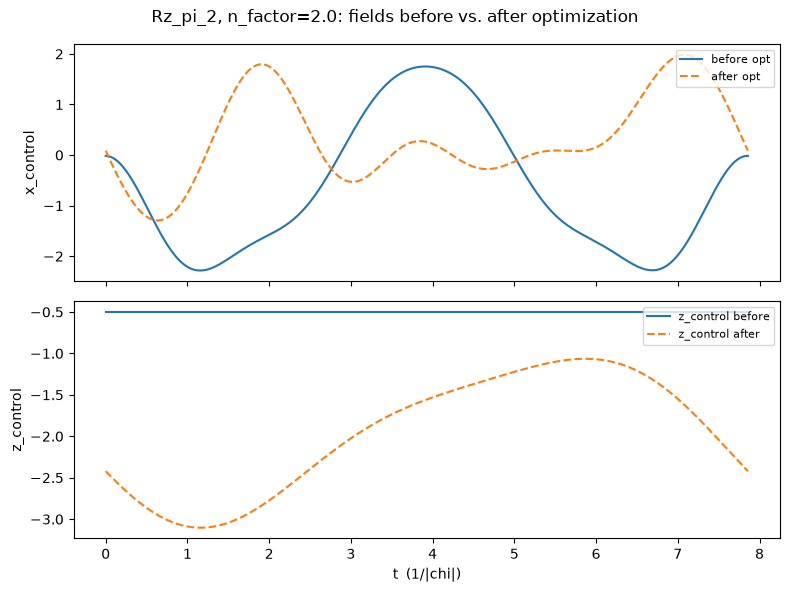

In [7]:
import matplotlib.pyplot as plt

cn_params_before, z_params_before = unpack(jnp.asarray(x0))
cn_params_after,  z_params_after  = unpack(jnp.asarray(best[1]))

x_control_before = np.asarray(x_scale * (Phi @ cn_params_before))
x_control_after  = np.asarray(x_scale * (Phi @ cn_params_after))
z_tr_before = np.asarray(chi/2 + Phi_z @ z_params_before)
z_tr_after  = np.asarray(chi/2 + Phi_z @ z_params_after)

fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

axes[0].plot(t_grid, x_control_before, label="before opt", linewidth=1.5)
axes[0].plot(t_grid, x_control_after,  label="after opt",  linewidth=1.5, linestyle="--")
axes[0].set_ylabel("x_control")
axes[0].legend(fontsize=8, loc="upper right")

axes[1].plot(t_grid, z_tr_before, label="z_control before", linewidth=1.5)
axes[1].plot(t_grid, z_tr_after,  label="z_control after",  linewidth=1.5, linestyle="--")
axes[1].set_ylabel("z_control")
axes[1].set_xlabel("t  (1/|chi|)")
axes[1].legend(fontsize=8, loc="upper right")

fig.suptitle(f"Rz_pi_2, n_factor={n_factor}: fields before vs. after optimization")
fig.tight_layout()


Restored: the full 8x8 Hamiltonian construction and joint-parity target/gates, built directly from the optimized fields above -- same structure as cell 17 / the joint-parity target cell of *Paper_results_and_figures.ipynb*.

In [8]:
# Additional operators in cavity_a ⊗ cavity_b ⊗ transmon space
Sx  = qt.tensor(qt.qeye(N_fock), qt.qeye(N_fock), qt.sigmax())  # transmon sigma_x
Sy  = qt.tensor(qt.qeye(N_fock), qt.qeye(N_fock), qt.sigmay())  # transmon sigma_y
n_a = a.dag() * a                                               # cavity a photon number
n_b = b.dag() * b                                               # cavity b photon number

# Optimized fields, on a fresh fine grid (N_points=4096)
N_points = 2**12
time_gate_1_3 = np.linspace(0, T_new, N_points)
s_full = time_gate_1_3 / T_new * T_g0
cos_full = np.cos(np.outer(s_full, harmonics)*w)
sin_full = np.sin(np.outer(s_full, harmonics)*w)
Phi_full = np.concatenate([np.ones((N_points,1)), cos_full, sin_full], axis=1)

cn_params_opt, z_params_opt = unpack(jnp.asarray(best[1]))
cn_params_opt = np.asarray(cn_params_opt)
z_params_opt = np.asarray(z_params_opt)

x_control = np.asarray(x_scale * (Phi_full @ cn_params_opt))
y_control = np.zeros_like(x_control)

z_cos_full = np.cos(np.outer(time_gate_1_3, z_harmonics)*(2*np.pi/T_new))
z_sin_full = np.sin(np.outer(time_gate_1_3, z_harmonics)*(2*np.pi/T_new))
Phi_z_full = np.concatenate([np.ones((N_points,1)), z_cos_full, z_sin_full], axis=1)
z_control = chi/2 + Phi_z_full @ z_params_opt

g_control = np.zeros_like(x_control)                            # beamsplitter coupling, g=0

# H = (g/2)(a†b + ab†) - (chi/2) n_a Sz + Omega_x/2 Sx + Omega_y/2 Sy + delta/2 Sz
H_robust_step_1_3 = [[n_a * Sz,                   -(chi/2)],
                     [(a.dag()*b + a*b.dag())/2, g_control],
                     [Sx/2,                      x_control],
                     [Sy/2,                      y_control],
                     [Sz/2,                      z_control]]

H_robust_step_1_3 = qt.QobjEvo(H_robust_step_1_3, tlist=time_gate_1_3)

U_step_1_3 = qt.propagator(H_robust_step_1_3, t=time_gate_1_3, args=None,
                              options={"max_step": 0.5/N_points, "atol": 1e-14, "rtol": 1e-14})

U_step_1_3[-1]


Quantum object: dims=[[2, 2, 2], [2, 2, 2]], shape=(8, 8), type='oper', dtype=Dense, isherm=False
Qobj data =
[[-7.07112246e-01+7.07101271e-01j -2.53402612e-04+7.46118125e-06j
   0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j]
 [ 2.53402612e-04+7.46118125e-06j -7.07112246e-01-7.07101271e-01j
   0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j]
 [ 0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
  -7.07112246e-01+7.07101271e-01j -2.53402612e-04+7.46118125e-06j
   0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j]
 [ 0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   2.53402612e-04+7.46118125e

In [10]:
P_00 = qt.tensor(qt.basis(N_fock,0)*qt.basis(N_fock,0).dag(), qt.basis(N_fock,0)*qt.basis(N_fock,0).dag(), qt.qeye(2))
P_11 = qt.tensor(qt.basis(N_fock,1)*qt.basis(N_fock,1).dag(), qt.basis(N_fock,1)*qt.basis(N_fock,1).dag(), qt.qeye(2))
X_cav = (a.dag()*b + a*b.dag())         + P_00 + P_11


from scipy.linalg import block_diag

# Joint parity target: 1j*I on |00> and |11> sectors, X_cav*Z_t on code space
u_jp_target_a = block_diag(-1j*I.full(), (X_cav*Sz)[2:6, 2:6], 1j*I.full())   # 8x8 numpy array

u_jp_target_b = block_diag(-I.full(), (X_cav*Sz)[2:6, 2:6], I.full())         # 8x8 numpy array


U_sim_1 = U_step_1_3[-1] * (Sz*X_cav) * U_step_1_3[-1]

fid_0 = tools.calculate_gate_fidelity(U_sim_1.full(), u_jp_target_a)
print(" ----------------- Infidelity ----------------\n")
print("             ", 1 - fid_0, "\n")
print(" ---------------------------------------------")


U_sim_1


 ----------------- Infidelity ----------------

              1.641631693916068e-07 

 ---------------------------------------------


Quantum object: dims=[[2, 2, 2], [2, 2, 2]], shape=(8, 8), type='oper', dtype=Dense, isherm=False
Qobj data =
[[ 1.55843920e-05-9.99999936e-01j -1.05516215e-05-3.58362619e-04j
   0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j]
 [-1.05516215e-05+3.58362619e-04j -1.55843920e-05-9.99999936e-01j
   0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j]
 [ 0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   9.99999877e-01+7.12006841e-06j -3.39453554e-04+3.61747173e-04j
   0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j]
 [ 0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e